In [17]:
"""
Many-Body Dephasing — Fast Simulation
======================================
Key idea: All modes are qubits and H = Σ χ_ij n_i n_j is diagonal
in the computational basis. Because n_i ∈ {0, 1}, the entire
time-evolution operator is a diagonal phase matrix. This means:

  * No QuTiP mesolve, no large sparse-matrix exponentiation.
  * A qubit state |ψ⟩ = α|0⟩ + β|1⟩ accumulates phase only in its
    |1⟩ component: β → β · exp(-i φ t) where φ = Σ_j χ_{0j} n_j.
  * We only need to track the *scalar phase* accumulated by mode 0's
    off-diagonal coherence.  Everything else is pure numpy arithmetic.

Speed-up vs original:
  * No 2^N tensor-product Hilbert space at all (was O(2^N) matrix ops).
  * Vectorised over all M Monte-Carlo trials simultaneously.
  * Gate "randomisation" reduces to a coin-flip that flips n_j ∈ {0,1}.
  * Runs in microseconds per timestep per trial.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import qutip as qt

# ─────────────────────────────────────────────────────────────────────────────
# 1.  State representation
# ─────────────────────────────────────────────────────────────────────────────
# Each qubit |ψ⟩ = α|0⟩ + β|1⟩.
# We only need n_j = |β_j|² ∈ {0,1} for modes j≥1 (they contribute phase kicks).
# For mode 0 we track (α₀, β₀) to compute ⟨e^{iφ(t)}⟩ = Re[α₀* β₀ / |α₀||β₀|]
# but actually we only need the *accumulated phase offset* on β₀.

# Cardinal states → n (occupation of |1⟩) for the "bath" modes (j ≥ 1).
# |0⟩→n=0, |1⟩→n=1, |+⟩→0.5, |-⟩→0.5, |+i⟩→0.5, |-i⟩→0.5
CARDINAL_N = np.array([0.0, 1.0, 0.5, 0.5, 0.5, 0.5])

# For mode 0 we need the coherence α₀*β₀ to track e^{iφ}.
# Initial state of mode 0: we always start in |+x⟩ = (|0⟩+|1⟩)/√2
# so α₀ = β₀ = 1/√2, coherence = 0.5.
# The phase accumulated on β₀ gives the decay of ⟨e^{iΦ}⟩.

# For the bath modes we need their *occupation* n_j (which drives phase kicks
# on mode 0) AND their full 2-vector so we can apply gates correctly.
# After a gate the new n_j changes.  We store n_j as a float in [0,1].

# "Refreshing one mode at random" → draw j ∈ {1,...,N-1} uniformly,
# draw a new cardinal state for it → update n_j.

# ─────────────────────────────────────────────────────────────────────────────
# 2.  Phase-kick arithmetic
# ─────────────────────────────────────────────────────────────────────────────
# At each timestep the |1⟩ component of mode 0 picks up phase:
#   δφ = Σ_{j=1}^{N-1} χ_{0j} · n_j
# Accumulated total: Φ(t) = Σ_{steps up to t} δφ_step
# The dephasing observable:  ⟨e^{iΦ(t)}⟩_MC  (average over trials)

# ─────────────────────────────────────────────────────────────────────────────
# 3.  Main simulation  (fully vectorised over M trials)
# ─────────────────────────────────────────────────────────────────────────────

def simulate_dephasing_fast(
    N: int,
    chi: float,
    T: int,
    M: int = 4000,
    chi_matrix: np.ndarray =None ,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Simulate ⟨e^{iΦ(t)}⟩ for mode 0 in a system of N qubits.

    Parameters
    ----------
    N         : total number of modes (mode 0 is tracked, 1..N-1 are bath)
    chi       : uniform cross-Kerr coupling χ_{0j} for all j≠0  [rad / step]
    T         : number of timesteps
    M         : number of Monte-Carlo trials (vectorised)
    chi_matrix: optional (N,N) array of χ_{ij}; if given, chi is ignored
    seed      : RNG seed

    Returns
    -------
    steps     : shape (T+1,)  — timestep indices 0, 1, …, T
    dephasing : shape (T+1,)  — |⟨e^{iΦ(t)}⟩| averaged over M trials
    """
    rng = np.random.default_rng(seed)

    # Build χ_{0j} vector (couplings from mode 0 to each bath mode j=1..N-1)
    if chi_matrix is not None:
        chi_0j = chi_matrix[0, 1:]          # shape (N-1,)
    else:
        chi_0j = np.full(N - 1, chi)        # shape (N-1,)

    # ── Initial bath occupations: shape (M, N-1) ──────────────────────────
    # Each bath mode j independently drawn from the 6 cardinal states.
    idx = rng.integers(0, 6, size=(M, N - 1))  # (M, N-1)
    n_bath = CARDINAL_N[idx]                    # (M, N-1)  floats in {0,.5,1}

    # ── Accumulated phase for mode 0's |1⟩ component: shape (M,) ──────────
    Phi = np.zeros(M)

    # ── Record dephasing at each step ──────────────────────────────────────
    steps = np.arange(T + 1)
    dephasing = np.empty(T + 1)
    dephasing[0] = 1.0        # t=0: perfect coherence

    for t in range(1, T + 1):
        # 1) Phase kick from current bath occupations
        #    δφ_m = Σ_j χ_{0j} n_{bath,m,j}   shape (M,)
        delta_phi = n_bath @ chi_0j            # (M,N-1) @ (N-1,) → (M,)
        Phi += delta_phi

        # 2) Refresh ONE random bath mode per trial
        j_refresh = rng.integers(0, N - 1, size=M)          # (M,) ∈ {0..N-2}
        new_idx   = rng.integers(0, 6,     size=M)           # new cardinal state
        new_n     = CARDINAL_N[new_idx]                      # (M,)
        # Scatter update: n_bath[m, j_refresh[m]] = new_n[m]
        n_bath[np.arange(M), j_refresh] = new_n

        # 3) Compute ⟨e^{iΦ}⟩
        dephasing[t] = np.abs(np.mean(np.exp(1j * Phi)))

    return steps, dephasing


# ─────────────────────────────────────────────────────────────────────────────
# 4.  QuTiP backend  (exact, slower, good for cross-checking small N)
# ─────────────────────────────────────────────────────────────────────────────

# Six cardinal states as QuTiP kets
def _cardinal_states_qt():
    g, e = qt.basis(2, 0), qt.basis(2, 1)
    return [
        g,                          # |0⟩
        e,                          # |1⟩
        (g + e).unit(),             # |+x⟩
        (g - e).unit(),             # |-x⟩
        (g + 1j * e).unit(),        # |+y⟩
        (g - 1j * e).unit(),        # |-y⟩
    ]

CARDINAL_STATES_QT = _cardinal_states_qt()


def simulate_dephasing_qutip(
    N: int,
    chi: float,
    T: int,
    M: int = 200,
    chi_matrix: np.ndarray  = None,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """
    QuTiP version of the many-body dephasing simulation.

    Computes ⟨e^{iΦ(t)}⟩ by tracking the full 2^N density matrix.

    At each timestep:
      1. Apply the cross-Kerr unitary U = exp(-i H · 1) to the state.
      2. Refresh one random bath mode by tracing it out and replacing
         with a freshly drawn cardinal state (equivalent to a projective
         reset followed by re-preparation).
      3. Record the off-diagonal coherence of mode 0:
           ⟨e^{iΦ}⟩ = ρ₀[0,1] / (√ρ₀[0,0] √ρ₀[1,1])  (normalised)

    Parameters
    ----------
    N         : total number of modes
    chi       : uniform χ_{0j} coupling  [rad / step]
    T         : number of timesteps
    M         : Monte-Carlo trials (NOT vectorised — loop over trials)
    chi_matrix: optional (N,N) coupling array; overrides chi
    seed      : RNG seed

    Returns
    -------
    steps     : shape (T+1,)
    dephasing : shape (T+1,)  — |⟨e^{iΦ(t)}⟩| averaged over M trials
    """
    rng = np.random.default_rng(seed)

    # ── Build χ matrix ────────────────────────────────────────────────────
    if chi_matrix is not None:
        X = chi_matrix
    else:
        X = np.full((N, N), chi)
        np.fill_diagonal(X, 0.0)

    # ── Number operators in the full 2^N Hilbert space ────────────────────
    def n_op(k):
        ops = [qt.qeye(2)] * N
        ops[k] = qt.num(2)
        return qt.tensor(ops)

    n_ops = [n_op(k) for k in range(N)]

    # ── Cross-Kerr Hamiltonian (diagonal → store as array for speed) ──────
    H = sum(
        X[i, j] * n_ops[i] * n_ops[j]
        for i in range(N) for j in range(i + 1, N)
    )
    # Unitary for one timestep: U = exp(-i H)  — precompute once
    U = (-1j * H).expm()
    Udag = U.dag()

    # ── Identity ops for tensor rebuilds ─────────────────────────────────
    I2 = qt.qeye(2)

    def embed_gate(gate_2x2, k):
        """Embed a single-qubit gate at position k into the full space."""
        ops = [I2] * N
        ops[k] = gate_2x2
        return qt.tensor(ops)

    steps = np.arange(T + 1)
    coherences = np.zeros((M, T + 1), dtype=complex)

    for trial in range(M):
        # ── Initial state: mode 0 in |+x⟩, bath modes random cardinal ────
        mode0_state = (qt.basis(2, 0) + qt.basis(2, 1)).unit()
        bath_states = [CARDINAL_STATES_QT[rng.integers(6)] for _ in range(N - 1)]
        psi = qt.tensor([mode0_state] + bath_states)
        rho = qt.ket2dm(psi)

        # t = 0 coherence
        rho0 = rho.ptrace(0)
        coherences[trial, 0] = _coherence(rho0)

        for t in range(1, T + 1):
            # 1) Unitary cross-Kerr evolution for one timestep
            rho = U * rho * Udag

            # 2) Refresh one random bath mode k ∈ {1, …, N-1}
            k = int(rng.integers(1, N))            # mode index in full space
            new_state = CARDINAL_STATES_QT[rng.integers(6)]

            # Trace out mode k and re-inject the new cardinal state
            # rho_rest = ptrace over all modes except k
            keep = list(range(N))
            keep.remove(k)
            rho_rest = rho.ptrace(keep)  # (N-1)-mode reduced state

            # Rebuild: rho_new = rho_rest ⊗ |new⟩⟨new|, then permute k back
            rho_new_state = qt.ket2dm(new_state)
            # Insert mode k at position k: tensor [modes 0..k-1, new, modes k+1..]
            # rho_rest has modes in order 0,1,..,k-1,k+1,..,N-1
            # Split and re-insert
            rho = _insert_mode(rho_rest, rho_new_state, k, N)

            # 3) Record coherence of mode 0
            rho0 = rho.ptrace(0)
            coherences[trial, t] = _coherence(rho0)

    # Average |⟨e^{iΦ}⟩| over trials
    dephasing = np.abs(np.mean(coherences, axis=0))
    return steps, dephasing


def _coherence(rho2x2):
    """
    Extract the normalised off-diagonal coherence of a single-qubit density matrix.
    Returns ρ[0,1] / sqrt(ρ[0,0] * ρ[1,1]), which equals e^{iΦ} for a pure dephased state.
    """
    r = rho2x2.full()
    p0, p1 = r[0, 0].real, r[1, 1].real
    if p0 * p1 < 1e-15:
        return 0.0 + 0j
    return r[0, 1] / np.sqrt(p0 * p1)


def _insert_mode(rho_rest, rho_new, k, N):
    """
    Given rho_rest (N-1 modes, in order 0..k-1, k+1..N-1) and a new single-mode
    density matrix rho_new, tensor them together and permute so that rho_new
    ends up at position k.

    The ptrace(keep) call where keep = [0,..,k-1, k+1,..,N-1] preserves the
    ordering, so rho_rest has indices 0..N-2 corresponding to original modes
    [0,..,k-1, k+1,..,N-1].  We need to insert rho_new at slot k.
    """
    if k == N - 1:
        # New mode goes last
        return qt.tensor(rho_rest, rho_new)
    elif k == 0:
        # New mode goes first
        return qt.tensor(rho_new, rho_rest)
    else:
        # Split rho_rest into [0..k-1] and [k..N-2] (N-1 modes total)
        # rho_rest is a (N-1)-mode object; we want to put rho_new at position k
        # Easiest: tensor as [..., rho_new at k, ...] directly
        # We tensor all N subsystems and permute
        # Build the full tensor with new mode appended, then permute
        rho_full = qt.tensor(rho_rest, rho_new)  # modes: 0..k-1, k+1..N-1, NEW
        # Current index of new mode = N-1 (last)
        # We want it at index k
        # Permutation: move last element to position k
        perm = list(range(N - 1))        # [0, 1, …, N-2]  (original ordering)
        perm.insert(k, N - 1)            # insert N-1 (new) at slot k
        return rho_full.permute(perm)


# ─────────────────────────────────────────────────────────────────────────────
# 5.  Fitting
# ─────────────────────────────────────────────────────────────────────────────

def exponential_decay(t, A, gamma, c):
    return A * np.exp(-gamma * t) + c


def fit_gamma(steps, dephasing):
    try:
        A0 = dephasing[0] - dephasing[-1]
        c0 = max(dephasing[-1], 0.0)
        half = dephasing[0] - 0.5 * A0
        idx  = np.argmin(np.abs(dephasing - half))
        g0   = np.log(2) / max(steps[idx], 1)
        popt, _ = curve_fit(
            exponential_decay, steps, dephasing,
            p0=[A0, g0, c0],
            bounds=([0, 1e-9, -0.1], [2, 10, 1.1]),
            maxfev=10000,
        )
        return popt[1], popt
    except Exception:
        return np.nan, None


# ─────────────────────────────────────────────────────────────────────────────
# 6.  Sweep over N  (choose backend: "fast" or "qutip")
# ─────────────────────────────────────────────────────────────────────────────

def sweep_N(
    N_range,
    chi      = 0.02 * np.pi,
    T        = 300,
    M        = 8000,
    seed     = 42,
    backend  = "fast",   # "fast" or "qutip"
):
    """
    Run the dephasing simulation for each N in N_range.

    backend = "fast"   → numpy-only, vectorised, handles large N/M/T easily.
    backend = "qutip"  → exact 2^N density-matrix simulation, good for
                         cross-checking small N (N ≤ 5 recommended).
    """
    sim_fn = simulate_dephasing_fast if backend == "fast" else simulate_dephasing_qutip
    results = {}
    for N in N_range:
        print(f"  N = {N} [{backend}] …", end=" ", flush=True)
        steps, deph = sim_fn(N=N, chi=chi, T=T, M=M, seed=seed)
        gamma, popt = fit_gamma(steps, deph)
        results[N] = dict(steps=steps, dephasing=deph, gamma=gamma, popt=popt)
        print(f"γ = {gamma:.5f}")
    return results


# ─────────────────────────────────────────────────────────────────────────────
# 7.  Plotting
# ─────────────────────────────────────────────────────────────────────────────

def plot_results(results, chi, T, M, backend="fast"):
    N_range = sorted(results.keys())
    n_cols  = len(N_range)

    # ── Panel A: dephasing traces ──────────────────────────────────────────
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4.5), sharey=True)
    if n_cols == 1:
        axes = [axes]
    palette = plt.cm.viridis(np.linspace(0.2, 0.85, n_cols))

    for ax, N, color in zip(axes, N_range, palette):
        r = results[N]
        steps, deph, gamma, popt = r["steps"], r["dephasing"], r["gamma"], r["popt"]

        ax.plot(steps, deph, lw=2, color=color, label=r"$|\langle e^{i\Phi}\rangle|$")
        if popt is not None and not np.isnan(gamma):
            t_sm = np.linspace(0, steps[-1], 400)
            ax.plot(t_sm, exponential_decay(t_sm, *popt), "r--", lw=1.5,
                    label=f"γ = {gamma:.4f}")
        ax.set_xlabel("Timestep", fontsize=11)
        ax.set_title(f"N = {N}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        # ax.set_ylim(-0.05, 1.1)
        ax.set_yscale("log")

    axes[0].set_ylabel(r"$|\langle e^{i\Phi(t)}\rangle|$", fontsize=12)
    fig.suptitle(
        rf"Many-body dephasing [{backend}]  ($\chi = {chi/np.pi:.3f}\pi$, $M = {M}$ trials)",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("outputs/dephasing_traces.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Panel B: γ vs N ────────────────────────────────────────────────────
    gammas = [results[N]["gamma"] for N in N_range]
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    ax2.plot(N_range, gammas, "o-", ms=9, lw=2.5, color="steelblue")

    # Try power-law fit γ ~ N^α
    try:
        log_fit = np.polyfit(np.log(N_range), np.log(gammas), 1)
        alpha   = log_fit[0]
        N_fine  = np.linspace(N_range[0], N_range[-1], 200)
        ax2.plot(N_fine, np.exp(log_fit[1]) * N_fine**alpha, "r--",
                 lw=1.5, label=f"power law: γ ∝ N^{{{alpha:.2f}}}")
        ax2.legend(fontsize=10)
    except Exception:
        pass

    ax2.set_xlabel("Number of modes N", fontsize=13)
    ax2.set_ylabel("Dephasing rate γ", fontsize=13)
    # ax2.set_yscale("log")
    # ax2.set_xscale("log")
    ax2.set_title("Dephasing rate vs mode number", fontsize=13, fontweight="bold")
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(N_range)
    plt.tight_layout()
    plt.savefig("outputs/gamma_vs_N.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Summary table ───────────────────────────────────────────────────────
    print(f"\n{'='*38}")
    print(f"{'N':>5}  {'γ':>12}")
    print(f"{'-'*38}")
    for N in N_range:
        print(f"{N:5d}  {results[N]['gamma']:12.6f}")
    print(f"{'='*38}")


# Test Fast

In [26]:
import time

chi  = 1e-3 * 2 * np.pi # 100 hz *2*pi 
T    = 1000 # timestep in mus
seed = 42

# ── Fast backend: large sweep ─────────────────────────────────────────
N_range_fast = [i for i in range(2, 15)]  # N = 2, 3, …, 14

M_fast = 10000
print("=== Fast (numpy) backend ===")
t0 = time.perf_counter()
results_fast = sweep_N(N_range_fast, chi=chi, T=T, M=M_fast, seed=seed, backend="fast")
print(f"Wall time: {time.perf_counter() - t0:.2f} s\n")




=== Fast (numpy) backend ===
  N = 2 [fast] … γ = 0.00000
  N = 3 [fast] … γ = 0.00004
  N = 4 [fast] … γ = 0.00008
  N = 5 [fast] … γ = 0.00004
  N = 6 [fast] … γ = 0.00007
  N = 7 [fast] … γ = 0.00010
  N = 8 [fast] … γ = 0.00017
  N = 9 [fast] … γ = 0.00021
  N = 10 [fast] … γ = 0.00023
  N = 11 [fast] … γ = 0.00028
  N = 12 [fast] … γ = 0.00036
  N = 13 [fast] … γ = 0.00044
  N = 14 [fast] … γ = 0.00048
Wall time: 7.14 s



In [ ]:
# plt.plot(results_fast[20]['dephasing'])
# plt.yscale('log')

KeyError: 20

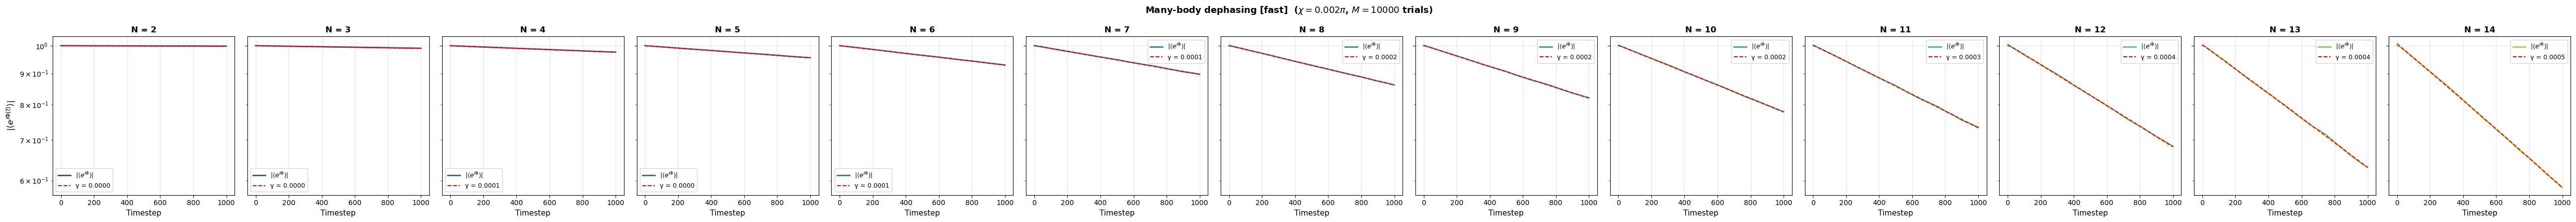

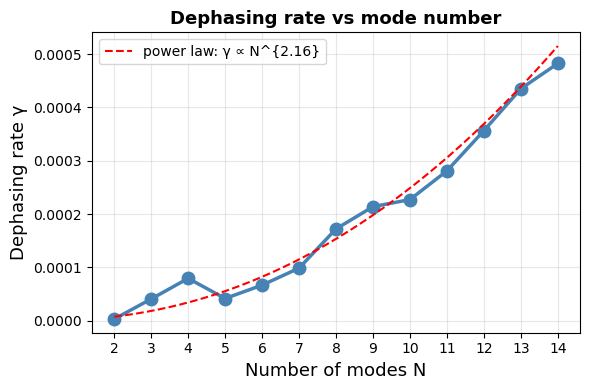


    N             γ
--------------------------------------
    2      0.000003
    3      0.000041
    4      0.000079
    5      0.000042
    6      0.000067
    7      0.000099
    8      0.000172
    9      0.000214
   10      0.000227
   11      0.000281
   12      0.000356
   13      0.000435
   14      0.000482


In [27]:
plot_results(results_fast, chi=chi, T=T, M=M_fast, backend="fast")

## Interpretation: 
1. At large mdoe number , profile of dephasing curves becomes more and more gaussian. 
2. Scaling with mode number looks like polynomial. 

# Qutip Simulation

In [28]:
chi = 1e-3 * 2 * np.pi # 1 khz *2*pi    

In [ ]:
# ── QuTiP backend: small N cross-check ───────────────────────────────
N_range_qt = [i for i in range(2, 15)]  # N = 2, 3, 4, 5
M_qt = 100
print("=== QuTiP backend (cross-check, small N) ===")
t0 = time.perf_counter()
results_qt = sweep_N(N_range_qt, chi=chi, T=T, M=M_qt, seed=seed, backend="qutip")
print(f"Wall time: {time.perf_counter() - t0:.2f} s\n")
plot_results(results_qt, chi=chi, T=T, M=M_qt, backend="qutip")

=== QuTiP backend (cross-check, small N) ===
  N = 2 [qutip] … γ = 0.00001
  N = 3 [qutip] … γ = 0.00004
  N = 4 [qutip] … γ = 0.00023
  N = 5 [qutip] … γ = 0.00013
  N = 6 [qutip] … γ = 0.00019
  N = 7 [qutip] … γ = 0.00031
  N = 8 [qutip] … γ = 0.00042
  N = 9 [qutip] … γ = 0.00053
  N = 10 [qutip] … γ = 0.00062
  N = 11 [qutip] … γ = 0.00092
  N = 12 [qutip] … γ = 0.00098
  N = 13 [qutip] … 

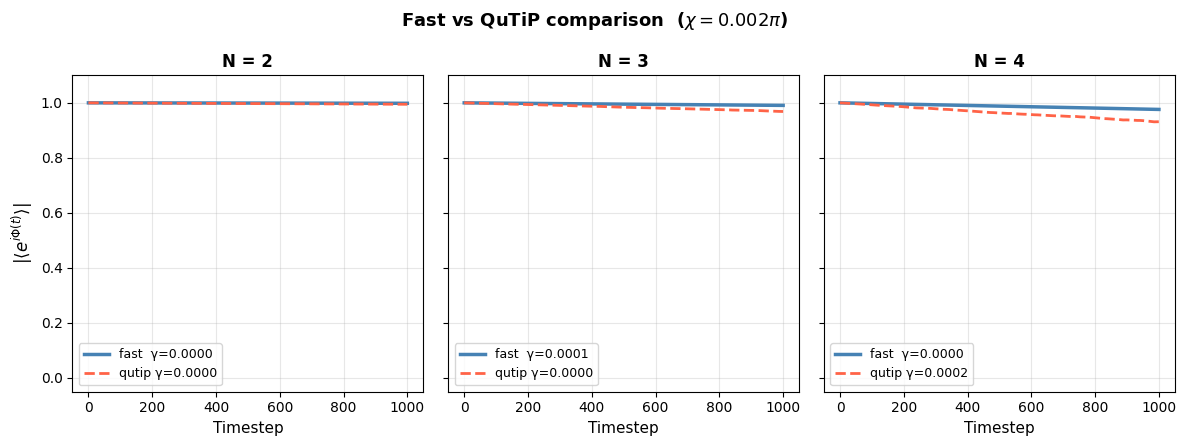

In [71]:
# ── Overlay comparison: fast vs qutip for N in {2,3,4} ───────────────
fig, axes = plt.subplots(1, len(N_range_qt), figsize=(4 * len(N_range_qt), 4.5), sharey=True)
if len(N_range_qt) == 1:
    axes = [axes]

for ax, N in zip(axes, N_range_qt):
    rf = results_fast[N]
    rq = results_qt[N]
    ax.plot(rf["steps"], rf["dephasing"], lw=2.5, color="steelblue",
            label=f"fast  γ={rf['gamma']:.4f}")
    ax.plot(rq["steps"], rq["dephasing"], lw=2, color="tomato",
            linestyle="--", label=f"qutip γ={rq['gamma']:.4f}")
    ax.set_title(f"N = {N}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Timestep", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

axes[0].set_ylabel(r"$|\langle e^{i\Phi(t)}\rangle|$", fontsize=12)
fig.suptitle(
    rf"Fast vs QuTiP comparison  ($\chi={chi/np.pi:.3f}\pi$)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("outputs/backend_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
plot_results(results_qt, chi=chi, T=T, M=M_qt, backend="qutip")